## Predicciones Precisas: Clasificación de Flores y Tumores

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/tenrjo9ryixw4mqpv9ys8v7jdr5q.png" width="50%">


## Objectives
- Usar Pandas para cargar conjuntos de datos.
- Identificar la variable objetivo y las características.
- Usar Regresión Logística para construir un clasificador.
- Usar métricas para evaluar el modelo.
- Hacer predicciones usando un modelo entrenado.


In [1]:
## Installar librerias necesarias
!pip install pandas==1.3.4
!pip install scikit-learn==0.20.1
!pip install pyspark==3.2.0

     ---------------------------------------- 0.0/4.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.7 MB ? eta -:--:--
     ------------------- -------------------- 2.4/4.7 MB 11.2 MB/s eta 0:00:01
     ---------------------------------------- 4.7/4.7 MB 11.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "C:\Users\masso\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "C:\Users\masso\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\masso\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
                 ^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\masso\AppData\Local\Temp\pip-build-env-7m35aril\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_w

     ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
     ---------- ----------------------------- 2.6/9.7 MB 13.7 MB/s eta 0:00:01
     -------------------------- ------------- 6.6/9.7 MB 16.8 MB/s eta 0:00:01
     ---------------------------------------- 9.7/9.7 MB 15.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "C:\Users\masso\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "C:\Users\masso\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\masso\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
                 ^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\masso\AppData\Local\Temp\pip-build-env-7uebky1w\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_w

     ---------------------------------------- 0.0/281.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.3 MB ? eta -:--:--
     --------------------------------------- 2.1/281.3 MB 10.7 MB/s eta 0:00:27
      -------------------------------------- 5.0/281.3 MB 12.1 MB/s eta 0:00:23
     - ------------------------------------- 7.6/281.3 MB 12.1 MB/s eta 0:00:23
     - ------------------------------------- 8.4/281.3 MB 12.1 MB/s eta 0:00:23
     - -------------------------------------- 9.4/281.3 MB 9.2 MB/s eta 0:00:30
     - ------------------------------------- 11.5/281.3 MB 9.1 MB/s eta 0:00:30
     - ------------------------------------- 13.6/281.3 MB 9.2 MB/s eta 0:00:30
     -- ------------------------------------ 15.7/281.3 MB 9.4 MB/s eta 0:00:29
     -- ------------------------------------ 18.4/281.3 MB 9.5 MB/s eta 0:00:28
     -- ------------------------------------ 20.7/281.3 MB 9.6 MB/s eta 0:00:28
     --- ----------------------------------- 22.0/281.

ERROR: Could not install packages due to an OSError: [WinError 32] El proceso no tiene acceso al archivo porque está siendo utilizado por otro proceso: 'c:\\users\\masso\\appdata\\roaming\\python\\python312\\site-packages\\pyspark\\jars\\aircompressor-2.0.2.jar'
Consider using the `--user` option or check the permissions.



### Importar librerias necesarias

In [2]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.linear_model import LogisticRegression

## Carga de datos


In [3]:
#  url de los datos de iris.
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/datasets/iris.csv"

# Usando funcion de pandas para cargar los datos en un dataframe.

df = pd.read_csv(URL)

In [4]:
# show 5 filas del dataframe
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
43,5.0,3.5,1.6,0.6,Iris-setosa
91,6.1,3.0,4.6,1.4,Iris-versicolor
130,7.4,2.8,6.1,1.9,Iris-virginica
30,4.8,3.1,1.6,0.2,Iris-setosa
12,4.8,3.0,1.4,0.1,Iris-setosa


In [5]:
# Tamaño del dataframe
df.shape

(150, 5)

<Axes: xlabel='Species'>

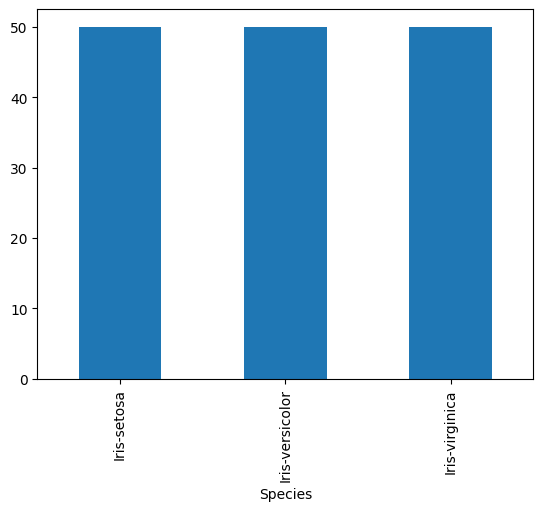

In [6]:
# Grafico de barras con la cantidad de cada especie
df.Species.value_counts().plot.bar()

## Separando las variables target del df


In [7]:
target = df["Species"]
features = df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]]

## Construir y entrenar classifier


In [8]:
# Creacion del modelo Logistic Regression
classifier = LogisticRegression()

In [9]:
# Entrenamiento del modelo
classifier.fit(features,target)

LogisticRegression()

## Evaluacion del modelo

In [13]:
# Evaluar el modelo
classifier.score(features,target)

0.9733333333333334

In [14]:
# Prediccion
classifier.predict([[5.4,2.6,4.1,1.3]])

array(['Iris-versicolor'], dtype=object)

# Extraccion para un modelo de cancer


In [19]:
URL2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/datasets/cancer.csv"
df2 = pd.read_csv(URL2)

target = df2["diagnosis"]
features = df2.drop("diagnosis",axis=1)

In [20]:
classifier2 = LogisticRegression()
classifier2.fit(features,target)

LogisticRegression()

### Evaluacion del modelo


In [22]:
# Evaluar el modelo
classifier2.score(features,target)

0.8998242530755711

In [23]:
classifier2.predict([[13.45,86.6,555.1,0.1022,0.08165,0.03974,0.1638]])

array(['Benign'], dtype=object)

<!-- ## Change Log -->


<!--
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-04-14|0.1|Ramesh Sannareddy|Initial Version Created|
|2023-06-20|0.3|Vicky Kuo|Proofreading|
-->
